In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('C:/Users/Hp/Downloads/dataset_pfa_complet.xls')
print(df.shape)       # nombre de lignes et colonnes
df.head(10)           # voir les 10 premières lignes

In [4]:
print("=== Valeurs nulles ===")
print(df.isnull().sum())

print("\n=== Doublons ===")
print(df.duplicated().sum())

print("\n=== Statistiques ===")
df.describe()

=== Valeurs nulles ===


NameError: name 'df' is not defined

In [ ]:
# Remplacer -127 par NaN
df.loc[df['temp'] == -127, 'temp'] = np.nan

# Vérifier combien il y en a
print("NaN après remplacement :", df['temp'].isnull().sum())

# Interpoler (remplacer NaN par la moyenne entre valeur avant et après)
df['temp'] = df['temp'].interpolate(method='linear')

print("NaN restants :", df['temp'].isnull().sum())
print("Temp min / max :", df['temp'].min(), "/", df['temp'].max())

In [7]:
# On supprime timestamp (heure = inutile pour le modèle ML)
df = df.drop(columns=['timestamp'])

print("Colonnes restantes :", list(df.columns))
df.head()


Colonnes restantes : ['vib_x', 'vib_y', 'vib_z', 'temp']


,vib_x,vib_y,vib_z,temp
0,-0.86,-6.51,-8.00,33.75
1,-0.63,-6.32,-8.20,33.75
2,-0.16,-6.63,-8.51,33.81
3,-0.67,-6.75,-7.88,33.81
4,-0.51,-6.43,-8.24,33.81


In [8]:
print("Shape finale :", df.shape)
print("Nulls restants :", df.isnull().sum().sum())
df.describe()

Shape finale : (8146, 4)
Nulls restants : 0


,vib_x,vib_y,vib_z,temp
count,8146.000000,8146.000000,8146.000000,8146.00000
mean,0.322876,-5.203233,7.812124,32.98266
std,1.174299,1.945350,2.078605,5.25673
min,-5.960000,-10.590000,-11.180000,27.50000
25%,-0.310000,-6.510000,7.340000,28.62000
50%,0.310000,-5.100000,8.280000,33.50000
75%,0.900000,-4.510000,8.710000,34.38000
max,9.610000,8.550000,13.220000,65.31000


In [9]:
df.to_csv("data_prete_pour_ml.csv", index=False)
print("Fichier sauvegardé !")

Fichier sauvegardé !


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data_prete_pour_ml.csv")
print(df.shape)
print(df.head())

(8146, 4)
   vib_x  vib_y  vib_z   temp
0  -0.86  -6.51  -8.00  33.75
1  -0.63  -6.32  -8.20  33.75
2  -0.16  -6.63  -8.51  33.81
3  -0.67  -6.75  -7.88  33.81
4  -0.51  -6.43  -8.24  33.81


In [4]:
print(df.columns.tolist())
print(df.isnull().sum())

['vib_x', 'vib_y', 'vib_z', 'temp']
vib_x    0
vib_y    0
vib_z    0
temp     0
dtype: int64


In [5]:
# On prend toutes les colonnes comme features
X = df[['vib_x', 'vib_y', 'vib_z', 'temp']]

# Normaliser les données (mettre tout à la même échelle)
# Important car temp est en °C et vib est en m/s² — échelles différentes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Données normalisées, shape :", X_scaled.shape)

Données normalisées, shape : (8146, 4)


In [8]:
model = IsolationForest(
    n_estimators=200,      # 200 arbres
    contamination=0.05,   # 6.2% d'anomalies dans ta data
    random_state=42        # pour avoir les mêmes résultats à chaque fois
)

model.fit(X_scaled)
print("Modèle entraîné !")

Modèle entraîné !


In [9]:
# Le modèle donne : 1 = normal, -1 = anomalie
df['prediction'] = model.predict(X_scaled)

# Score : plus c'est négatif, plus c'est une anomalie
df['anomaly_score'] = model.score_samples(X_scaled)

# Colonne plus lisible : True = anomalie
df['is_anomaly'] = df['prediction'] == -1

print(df['is_anomaly'].value_counts())
print(f"\nNombre d'anomalies détectées : {df['is_anomaly'].sum()}")
print(f"Pourcentage : {100 * df['is_anomaly'].mean():.1f}%")

is_anomaly
False    7738
True      408
Name: count, dtype: int64

Nombre d'anomalies détectées : 408
Pourcentage : 5.0%


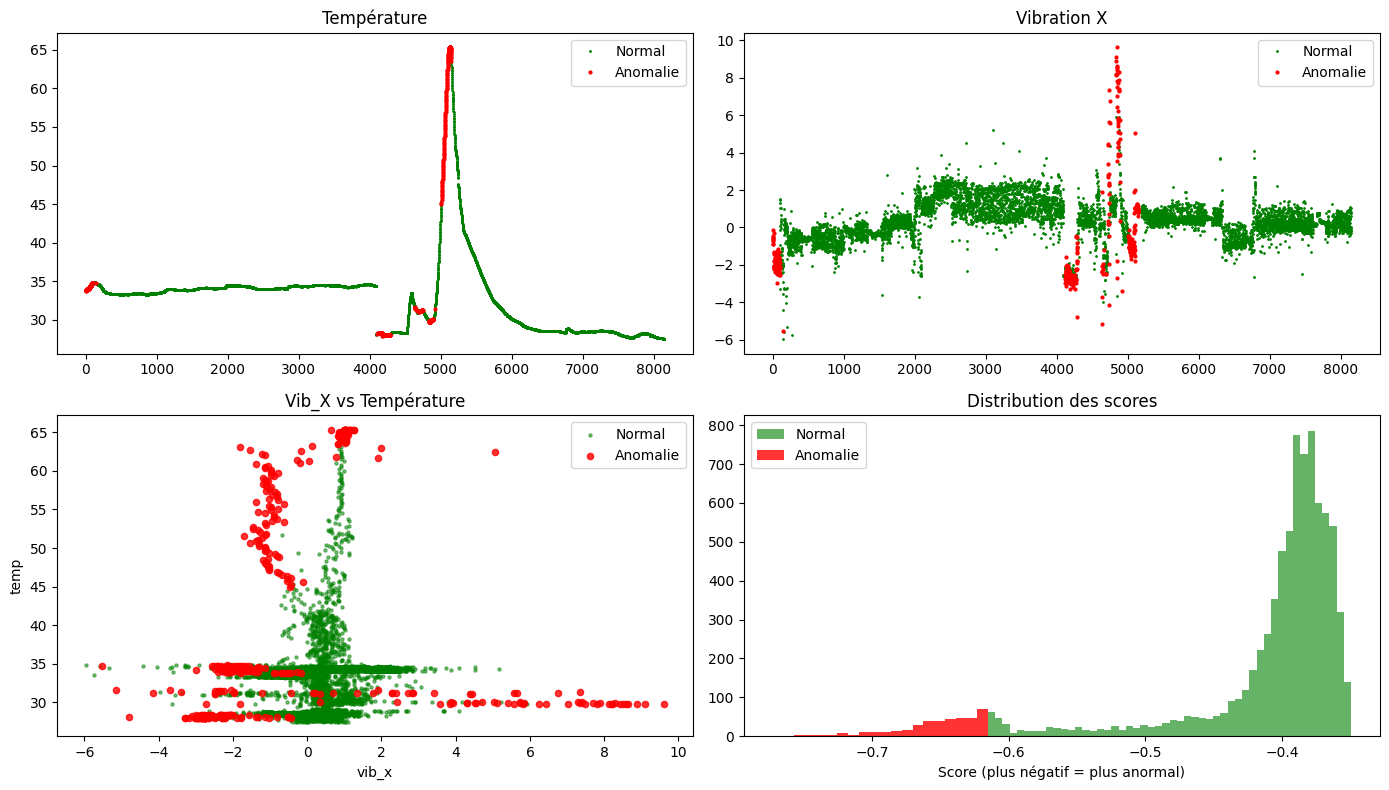

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Normal vs Anomalie en couleur
normal  = df[df['is_anomaly'] == False]
anomalie = df[df['is_anomaly'] == True]

# Graphique 1 : Température
axes[0,0].plot(normal.index,  normal['temp'],   '.', color='green', markersize=2, label='Normal')
axes[0,0].plot(anomalie.index, anomalie['temp'], '.', color='red',   markersize=4, label='Anomalie')
axes[0,0].set_title('Température')
axes[0,0].legend()

# Graphique 2 : Vibration X
axes[0,1].plot(normal.index,  normal['vib_x'],   '.', color='green', markersize=2, label='Normal')
axes[0,1].plot(anomalie.index, anomalie['vib_x'], '.', color='red',   markersize=4, label='Anomalie')
axes[0,1].set_title('Vibration X')
axes[0,1].legend()

# Graphique 3 : Scatter vib_x vs temp
axes[1,0].scatter(normal['vib_x'],   normal['temp'],   s=5,  color='green', alpha=0.5, label='Normal')
axes[1,0].scatter(anomalie['vib_x'], anomalie['temp'], s=20, color='red',   alpha=0.8, label='Anomalie')
axes[1,0].set_xlabel('vib_x')
axes[1,0].set_ylabel('temp')
axes[1,0].set_title('Vib_X vs Température')
axes[1,0].legend()

# Graphique 4 : Distribution des scores
axes[1,1].hist(normal['anomaly_score'],   bins=50, color='green', alpha=0.6, label='Normal')
axes[1,1].hist(anomalie['anomaly_score'], bins=20, color='red',   alpha=0.8, label='Anomalie')
axes[1,1].set_title('Distribution des scores')
axes[1,1].set_xlabel('Score (plus négatif = plus anormal)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Combien de tes anomalies thermiques (temp > 38) ont été détectées ?
anomalies_thermiques = df[df['temp'] > 38]
bien_detectees = anomalies_thermiques[anomalies_thermiques['is_anomaly'] == True]
ratees = anomalies_thermiques[anomalies_thermiques['is_anomaly'] == False]

print("=== Vérification ===")
print(f"Tes vraies anomalies thermiques (temp > 38°C) : {len(anomalies_thermiques)}")
print(f"Bien détectées par le modèle : {len(bien_detectees)}")
print(f"Ratées par le modèle         : {len(ratees)}")
print(f"Précision sur anomalies thermiques : {100*len(bien_detectees)/len(anomalies_thermiques):.1f}%")

print()

# Anomalies détectées qui ne sont PAS thermiques (vibration ?)
fausses = df[(df['is_anomaly'] == True) & (df['temp'] <= 38)]
print(f"Anomalies vibratoires détectées (temp normale) : {len(fausses)}")
print(f"Temp moyenne de ces points : {fausses['temp'].mean():.2f}°C")
print(fausses[['vib_x','vib_y','vib_z','temp','anomaly_score']].head(10))

=== Vérification ===
Tes vraies anomalies thermiques (temp > 38°C) : 508
Bien détectées par le modèle : 140
Ratées par le modèle         : 368
Précision sur anomalies thermiques : 27.6%

Anomalies vibratoires détectées (temp normale) : 268
Temp moyenne de ces points : 31.06°C
   vib_x  vib_y  vib_z   temp  anomaly_score
0  -0.86  -6.51  -8.00  33.75      -0.639555
1  -0.63  -6.32  -8.20  33.75      -0.635264
2  -0.16  -6.63  -8.51  33.81      -0.634644
3  -0.67  -6.75  -7.88  33.81      -0.644271
4  -0.51  -6.43  -8.24  33.81      -0.636996
5  -0.55  -6.67  -8.16  33.81      -0.640413
6  -0.90  -6.63  -8.04  33.81      -0.646068
7  -0.43  -6.47  -8.00  33.81      -0.632181
8  -0.71  -6.63  -8.00  33.81      -0.640835
9  -0.27  -7.26  -8.43  33.88      -0.652005


In [12]:
# Calculer la magnitude (force totale, indépendante de l'orientation)
df['magnitude'] = np.sqrt(df['vib_x']**2 + df['vib_y']**2 + df['vib_z']**2)

# Voir si la magnitude change entre normal et anomalie thermique
print("Magnitude quand NORMAL (temp <= 38°C) :")
print(df[df['temp'] <= 38]['magnitude'].describe().round(3))

print("\nMagnitude quand ANOMALIE (temp > 38°C) :")
print(df[df['temp'] > 38]['magnitude'].describe().round(3))

Magnitude quand NORMAL (temp <= 38°C) :
count    7638.000
mean        9.842
std         0.258
min         7.206
25%         9.730
50%         9.837
75%         9.947
max        12.464
Name: magnitude, dtype: float64

Magnitude quand ANOMALIE (temp > 38°C) :
count    508.000
mean      10.430
std        0.461
min        9.726
25%       10.065
50%       10.284
75%       10.745
max       13.253
Name: magnitude, dtype: float64


In [13]:
# Utiliser seulement magnitude + temp
X2 = df[['magnitude', 'temp']]

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

model2 = IsolationForest(
    n_estimators=200,
    contamination=0.062,
    random_state=42
)

model2.fit(X2_scaled)

df['prediction2']     = model2.predict(X2_scaled)
df['score2']          = model2.score_samples(X2_scaled)
df['is_anomaly2']     = df['prediction2'] == -1

print(f"Anomalies détectées : {df['is_anomaly2'].sum()}")

Anomalies détectées : 505


In [14]:
anomalies_thermiques = df[df['temp'] > 38]
bien_detectees = anomalies_thermiques[anomalies_thermiques['is_anomaly2'] == True]
ratees = anomalies_thermiques[anomalies_thermiques['is_anomaly2'] == False]

print("=== Résultats nouveau modèle ===")
print(f"Vraies anomalies thermiques    : {len(anomalies_thermiques)}")
print(f"Bien détectées                 : {len(bien_detectees)}")
print(f"Ratées                         : {len(ratees)}")
print(f"Précision                      : {100*len(bien_detectees)/len(anomalies_thermiques):.1f}%")

fausses = df[(df['is_anomaly2'] == True) & (df['temp'] <= 38)]
print(f"\nFausses alertes (temp normale) : {len(fausses)}")

=== Résultats nouveau modèle ===
Vraies anomalies thermiques    : 508
Bien détectées                 : 335
Ratées                         : 173
Précision                      : 65.9%

Fausses alertes (temp normale) : 170


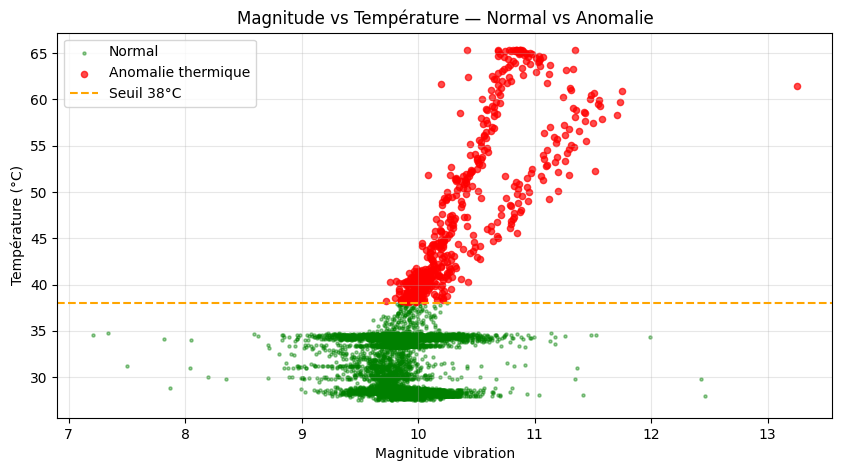

In [15]:
plt.figure(figsize=(10, 5))

normal_data   = df[df['temp'] <= 38]
anomalie_data = df[df['temp'] > 38]

plt.scatter(normal_data['magnitude'],   normal_data['temp'],
            s=5, color='green', alpha=0.4, label='Normal')
plt.scatter(anomalie_data['magnitude'], anomalie_data['temp'],
            s=20, color='red', alpha=0.7, label='Anomalie thermique')

plt.xlabel('Magnitude vibration')
plt.ylabel('Température (°C)')
plt.title('Magnitude vs Température — Normal vs Anomalie')
plt.axhline(y=38, color='orange', linestyle='--', linewidth=1.5, label='Seuil 38°C')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Ajouter une feature qui dit clairement si temp est haute
df['temp_haute'] = (df['temp'] - 38).clip(lower=0)
# si temp = 35 → temp_haute = 0 (normal)
# si temp = 45 → temp_haute = 7 (anomalie)

X3 = df[['magnitude', 'temp', 'temp_haute']]

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

model3 = IsolationForest(
    n_estimators=200,
    contamination=0.062,
    random_state=42
)

model3.fit(X3_scaled)

df['prediction3'] = model3.predict(X3_scaled)
df['score3']      = model3.score_samples(X3_scaled)
df['is_anomaly3'] = df['prediction3'] == -1

# Vérification
anomalies_thermiques = df[df['temp'] > 38]
bien_detectees = anomalies_thermiques[anomalies_thermiques['is_anomaly3'] == True]
ratees         = anomalies_thermiques[anomalies_thermiques['is_anomaly3'] == False]
fausses        = df[(df['is_anomaly3'] == True) & (df['temp'] <= 38)]

print("=== Résultats modèle amélioré ===")
print(f"Vraies anomalies thermiques : {len(anomalies_thermiques)}")
print(f"Bien détectées              : {len(bien_detectees)}")
print(f"Ratées                      : {len(ratees)}")
print(f"Précision                   : {100*len(bien_detectees)/len(anomalies_thermiques):.1f}%")
print(f"Fausses alertes             : {len(fausses)}")

=== Résultats modèle amélioré ===
Vraies anomalies thermiques : 508
Bien détectées              : 455
Ratées                      : 53
Précision                   : 89.6%
Fausses alertes             : 50


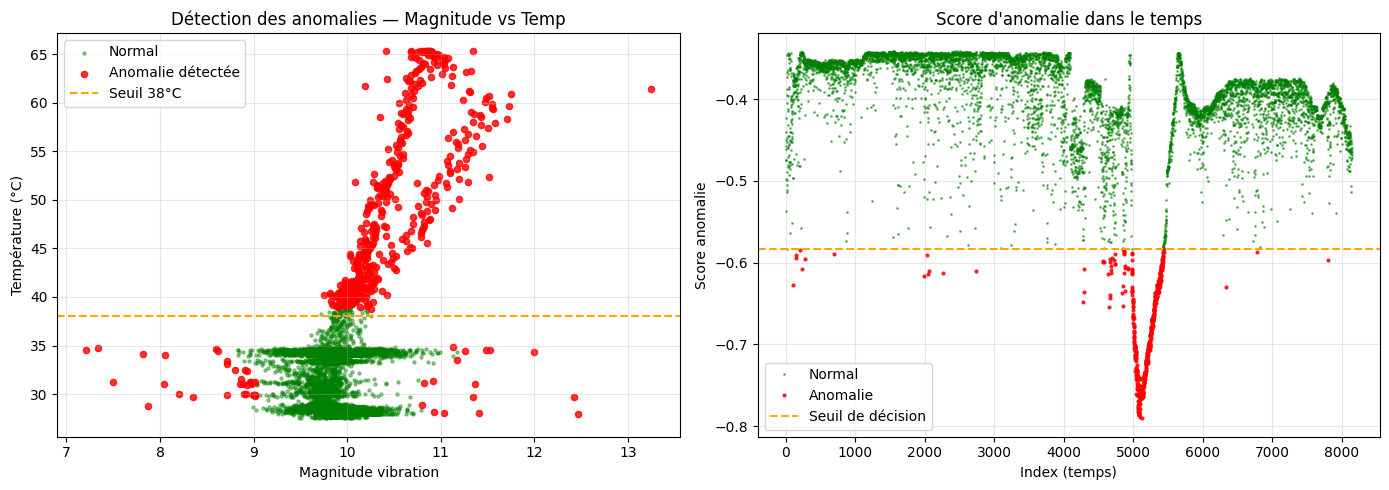

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal   = df[df['is_anomaly3'] == False]
anomalie = df[df['is_anomaly3'] == True]

# Graphique 1 : Magnitude vs Température
axes[0].scatter(normal['magnitude'],   normal['temp'],
                s=5,  color='green', alpha=0.4, label='Normal')
axes[0].scatter(anomalie['magnitude'], anomalie['temp'],
                s=20, color='red',   alpha=0.8, label='Anomalie détectée')
axes[0].axhline(y=38, color='orange', linestyle='--', linewidth=1.5, label='Seuil 38°C')
axes[0].set_xlabel('Magnitude vibration')
axes[0].set_ylabel('Température (°C)')
axes[0].set_title('Détection des anomalies — Magnitude vs Temp')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Score d'anomalie dans le temps
axes[1].plot(normal.index,   normal['score3'],   '.', color='green',
             markersize=2, alpha=0.5, label='Normal')
axes[1].plot(anomalie.index, anomalie['score3'], '.', color='red',
             markersize=4, alpha=0.8, label='Anomalie')
axes[1].axhline(y=model3.offset_, color='orange', linestyle='--',
                linewidth=1.5, label='Seuil de décision')
axes[1].set_xlabel('Index (temps)')
axes[1].set_ylabel('Score anomalie')
axes[1].set_title('Score d\'anomalie dans le temps')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
import joblib

# Sauvegarder le modèle et le scaler
joblib.dump(model3,   'modele_isolation_forest.pkl')
joblib.dump(scaler3,  'scaler.pkl')

# Sauvegarder les résultats
df.to_csv('resultats_finaux.csv', index=False)

print("Modèle sauvegardé : modele_isolation_forest.pkl")
print("Scaler sauvegardé : scaler.pkl")
print("Résultats sauvegardés : resultats_finaux.csv")

Modèle sauvegardé : modele_isolation_forest.pkl
Scaler sauvegardé : scaler.pkl
Résultats sauvegardés : resultats_finaux.csv


In [19]:
import os
print(os.getcwd())

C:\Users\Hp
